**ANALISI DI UN DATASET E CREAZIONE DI UN CLASSIFICATORE CON METODO NEAREST NEIGHBOR**

Il dataset utilizzato (https://huggingface.co/datasets/nataliaElv/banking77_topic_and_sentiment?row=3) contiene le interazioni dei clienti con un servizio di assistenza bancario. I testi sono stati pre-etichettati con topics e sentiment, connotati dalla dicitura "suggestion" nelle colonne in cui sono conservati. Partendo dai dati presenti, bisognerà realizzare un classificatore basato sul metodo Nearest Neighbor e analizzarne le prestazioni.

Statistiche da realizzare: confronto testo/topic finalizzato all'individuazione di lemmi chiave semanticamente rilevanti; misurazione dei testi con sentiment negativo associati a ciascun topic.

INDICE:

INSTALLAZIONE E IMPORTAZIONE DELLE LIBRERIE

CARICAMENTO DEL DATASET

1. DATA PRE-PROCESSING
      - 1.1. Data cleaning
      - 1.2. Lemmatizzazione

2. EMBEDDINGS GENERATION

3. TRAINING DEL MODELLO

4. VALIDATION
    - 4.1. Report delle prestazioni del classificatore con gli strumenti di Scikit.learn
    - 4.2. Dettaglio delle prestazioni mediante l'uso di Pandas

5. STATISTICS
    - 5.1. Confronto testo/topic e individuazione dei lemmi chiave
    - 5.2. Misurazione dei testi con sentiment negativo associati a ciascun topic.

**INSTALLAZIONE E IMPORTAZIONE DELLE LIBRERIE**

In [34]:
# forza l'installazione delle librerie mancanti nel kernel attuale
%pip install datasets sentence-transformers spacy pandas numpy matplotlib scikit-learn

# scarica il modello linguistico di SpaCy per questo kernel specifico
import sys
!{sys.executable} -m spacy download en_core_web_sm

Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 1.7 MB/s  0:00:07m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [35]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import en_core_web_sm
import re
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import spacy

**CARICAMENTO DEL DATASET**

In [36]:
dataset = load_dataset("nataliaElv/banking77_topic_and_sentiment")

data = pd.DataFrame(dataset['train'])
print(data)

                                                   text topics  \
0                              How do I locate my card?     []   
1     I still have not received my new card, I order...     []   
2     I ordered a card but it has not arrived. Help ...     []   
3      Is there a way to know when my card will arrive?     []   
4                          My card has not arrived yet.     []   
...                                                 ...    ...   
3075      If i'm not in the UK, can I still get a card?     []   
3076                 How many countries do you support?     []   
3077              What countries do you do business in?     []   
3078             What are the countries you operate in.     []   
3079         Can the card be mailed and used in Europe?     []   

                        topics-suggestion  \
0                                    None   
1                   [order_physical_card]   
2     [card_arrival, order_physical_card]   
3                          

**1. DATA PRE-PROCESSING**

La fase di pre-processing del dataset è suddivisa in due parti: la prima di data cleaning vero e proprio, la seconda di lemmatizzazione dei testi.

**1.1 Data cleaning:**
- controllo dei duplicati
- rimozione delle righe con valore 'null' nella colonna 'topics-suggestion'
- rimozione righe con più di un topic
- suddivisione del dataset in train (80%) e test (20%)

Come prima cosa, viene effettuato un controllo dei duplicati sulla colonna 'text' per garantire una maggiore coerenza dei dati.

In [37]:
duplicated_text = data[data['text'].duplicated()]   # viene utilizzata duplicated(), funzione di pandas che restituisce un valore booleano True quando si trova di fronte a un duplicato
print(f"numero di duplicati: {len(duplicated_text)}")

numero di duplicati: 0


All'interno della colonna 'topics-suggestion' vi sono alcune righe con valore 'null', se ne effettua la rimozione, poiché 'null' è un type che interferirebbe con il processo di NLP.

In [38]:
row_w_null = data.shape[0]  # shape(), attributo di pandas che restituisce una tupla con le dimensioni del dataset (n. righe, n. colonne); [0] seleziona il primo elemento
print(f"numero righe prima della rimozione: {row_w_null}")
print("\n")

# eliminazione delle righe con valore null
data_clean = data[data['topics-suggestion'].notna()]   # notna(), metodo di pandas che filtra la colonna selezionata restituendo solo le righe contenenti valori NON nulli (NaN o None)
print(f"numero righe dopo la rimozione: {data_clean.shape[0]}")

# reset dell'indice
data_clean = data_clean.reset_index(drop=True)  # reset_index(), funzione di pandas che inizializza un nuovo indice; (drop=True) scarta l'indice vecchio

# print di controllo delle prime 10 righe di 'text' e 'topics-suggestion'
print(data_clean[['text','topics-suggestion']][:10])


numero righe prima della rimozione: 3080


numero righe dopo la rimozione: 2901
                                                text  \
0  I still have not received my new card, I order...   
1  I ordered a card but it has not arrived. Help ...   
2   Is there a way to know when my card will arrive?   
3                       My card has not arrived yet.   
4                        i have not received my card   
5                How long does a card delivery take?   
6  I have been waiting longer than expected for m...   
7                 Why hasn't my card been delivered?   
8  Where is my new card? I have been waiting a week!   
9  My card still hasn't arrived after 2 weeks. Is...   

                                   topics-suggestion  
0                              [order_physical_card]  
1                [card_arrival, order_physical_card]  
2                                     [card_arrival]  
3                                     [card_arrival]  
4               [transfer_no

A diversi testi è stata assegnata più di una label alla colonna 'topics-suggestion', cosa che complica il lavoro del classificatore. Sono state considerate due opzioni: dopo aver valutato attentamente se ridurre a 1 i topic suggeriti per ogni testo, mantenendo le 2901 righe del dataset, ma modificando la naturalezza dei dati, oppure lavorare solamente con gli elementi che presentano un solo topic, riducendone però drasticamente il numero, si è preferito non intaccare la struttura del dataset, e dunque di effettuare un'operazione di selezione (anche se pesante), consci che la quantità limitata di dati potrebbe gravare sull'accuratezza del classificatore.    

In [39]:
# filtraggio delle righe con 1 solo topic alla colonna 'topics-suggestion'
data_filtered = data_clean[[len(topics) == 1 for topics in data_clean['topics-suggestion']]]   # utilizzo della list comprehension

# reset dell'indice: è necessario di nuovo poiché sono state rimosse altre righe
data_filtered = data_filtered.reset_index(drop= True)

# print di controllo
print(f'righe dopo il filtraggio: {len(data_filtered)}')
print('\n')
print(data_filtered[['text', 'topics-suggestion']])

righe dopo il filtraggio: 959


                                                  text  \
0    I still have not received my new card, I order...   
1     Is there a way to know when my card will arrive?   
2                         My card has not arrived yet.   
3                          i have not received my card   
4    Where is my new card? I have been waiting a week!   
..                                                 ...   
954      If i'm not in the UK, can I still get a card?   
955                 How many countries do you support?   
956              What countries do you do business in?   
957             What are the countries you operate in.   
958         Can the card be mailed and used in Europe?   

                        topics-suggestion  
0                   [order_physical_card]  
1                          [card_arrival]  
2                          [card_arrival]  
3    [transfer_not_received_by_recipient]  
4                          [card_arrival]  
..     

Viene applicata la funzione train_test_split() di sklearn per dividere in train (80%) e test (20%) il dataset.

In [40]:
train_data, test_data = train_test_split(data_filtered, test_size=0.2, random_state=42)   # random_state=42 è un parametro che fa sì che la divisione sia sempre uguale ad ogni esecuzione del codice.

print(f"righe train set: {train_data.shape[0]}")
print(f"righe test set: {test_data.shape[0]}")

righe train set: 767
righe test set: 192


**1.2 Lemmatizzazione:**

Viene dichiarata una funzione 'lemmatizator', che utilizza un oggetto 'nlp' (dichiarato in precedenza), in cui è stato caricato il modello linguistico pre addestrato 'en_core_web_sm' di SpaCy per la lemmatizzazione dei testi.

In [41]:
# nlp: oggetto in cui viene caricato il modello linguistico di SpaCy
nlp = spacy.load('en_core_web_sm')

In [42]:
# lemmatizator: funzione che effettua la lemmatizzazione
def lemmatizator(text):
    doc = nlp(text)   # passa l'argomento al modello linguistico
    lemmatized = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]  # usa la list comprehension per selezionare i lemmi dei token
    return " ".join(lemmatized) # utilizza join() per unire i lemmi in un'unica stringa separati da uno spazio

In [43]:
# applicazione della funzione lemmatizator al train set e al test set con il metodo apply()
train_data['lemmatized-text'] = train_data['text'].apply(lemmatizator)  # viene aggiunta ai dataset una nuova colonna che altro non è che la colonna 'text' a cui è stata applicata la funzione
test_data['lemmatized-text'] = test_data['text'].apply(lemmatizator)

# print di controllo delle prime 10 righe delle colonne 'text' e 'lemmatized-text' del train set
print(train_data[['text', 'lemmatized-text']][:10])

                                                  text  \
302                          How to change my address.   
467       How do I reset a forgotten passcode, please?   
294  there is a transaction on my account that i di...   
548              The ATM didn't give me the card back!   
465               Something is wrong with my password.   
109          Need help with my card. It's not working.   
77                           How do I use auto top up?   
754                  I need a few more physical cards.   
259  Can I use my card for payment all over the world?   
82   How do I make sure I don't run out of money on...   

                lemmatized-text  
302              change address  
467       reset forget passcode  
294     transaction account not  
548                    ATM card  
465              wrong password  
109         need help card work  
77                     use auto  
754          need physical card  
259      use card payment world  
82   sure run money c

**2. EMBEDDINGS GENERATION**

In questa fase viene caricato, in un oggetto 'model', il modello di SentenceTransformer 'distiluse-base-multilingual-cased-v1' basato su BERT, che viene successivamente utlizzato per il calcolo degli embeddings sia del train set che del test set.

In [44]:
# model: oggetto in cui viene caricato il modello linguistico per il calcolo degli embeddings
model = SentenceTransformer('distiluse-base-multilingual-cased-v1')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6257.54it/s]


In [45]:
# calcolo degli embeddings
train_embeddings = model.encode(train_data['lemmatized-text'].tolist())   # viene utilizzata tolist(), funzione di pandas che permette di convertire la colonna di un DataFrame in una lista di stringhe
test_embeddings = model.encode(test_data['lemmatized-text'].tolist())

# print di controllo
print(f'train set: {train_embeddings.shape}')
print(f'test set: {test_embeddings.shape}')

train set: (767, 512)
test set: (192, 512)


**3. TRAINING DEL MODELLO**

La funzione/classificatore 'predictor' prende tre argomenti (gli embedding del test set, gli embedding del train set, le label associate al train set), itera attraverso ciascun elemento del test set e ne calcola la similarità coseno rispetto ad ogni elemento del train set. Successivamente, identifica l'indice di massima similarità e ne aggiunge il valore (label) corrispondente a una lista vuota, seguendo il metodo Nearest Neighbor.

In [46]:
# predictor: funzione/classificatore per la topic/sentiment analysis secondo il metodo Nearest Neighbor
def predictor (test_embeddings, train_embeddings, train_label):   # prende come argomento due liste di embedding (test, train) e le label note (train)
  predicted = []  # crea una lista vuota in cui inserire le label calcolate
  for test_embedding in test_embeddings:  # itera attraverso ciascun elemento del test set
    similarities = cos_sim(test_embedding, train_embeddings)  # calcola la similarità di ciascun elemento con ciascun elemento del train set utilizzando la funzione cos_sim() di sentence_transformers
    index_most_similar = np.argmax(similarities).item()  # utilizza la funzione di numpy argmax() per estrarre l'elemento più simile
    predicted.append(train_label.values[index_most_similar])  # aggiunge il valore corrispondente all'indice più simile alla lista.
  return predicted  # restituisce la lista

In [47]:
# calcolo topic
predicted_topics = predictor(test_embeddings, train_embeddings, train_data['topics-suggestion'])

# creazione di una nuova colonna con le label predette dal classificatore
test_data['predicted-topics'] = predicted_topics

# print di controllo
print(test_data[['text', 'topics-suggestion', 'predicted-topics']][:10])

                                                  text  \
836            Is it okay to use a bank card to top up   
477  What steps do I take to receive another passcode?   
350                            Can I get a mastercard?   
892  My card is about to expire. How much does it c...   
855                           Please, activate my card   
261                 Can I use my card anywhere I want?   
215       I want to go back on what I did this morning   
334           How do I set-up my PIN for the new card?   
86   Can I space out how often money is transferred...   
877  My account got charged for taking out cash, wh...   

                    topics-suggestion         predicted-topics  
836  [top_up_by_bank_transfer_charge]            [atm_support]  
477              [passcode_forgotten]     [passcode_forgotten]  
350              [visa_or_mastercard]     [visa_or_mastercard]  
892            [card_about_to_expire]   [card_about_to_expire]  
855                [activate_my_card

**4. VALIDATION**

Vengono estratte le label corrispondenti ai topics (suggeriti e predetti) dalle liste in cui sono annidate. Il passaggio serve a preparare i dati in un formato che Scikit possa leggere.

Vengono calcolate le metriche principali (accuracy, precision, recall, F1-score) per la valutazione delle prestazioni del classificatore con gli strumenti di Scikit-Learn. Successivamente, si utilizza pandas per analizzare più in dettaglio gli stessi risultati.

**4.1 Report delle prestazioni del classificatore con gli strumenti di Scikit.learn**
- estrazione dei topic suggeriti e dei topic predetti
- accuracy
- classification report
- confusion matrix

Numero topic: 48


Accuracy: 0.765625


Classification report:
                                                  precision    recall  f1-score   support

                                activate_my_card       1.00      0.89      0.94         9
                                       age_limit       0.67      1.00      0.80         2
                         apple_pay_or_google_pay       1.00      1.00      1.00         6
                                     atm_support       0.78      0.70      0.74        10
                                automatic_top_up       1.00      0.67      0.80         3
balance_not_updated_after_cheque_or_cash_deposit       1.00      1.00      1.00         1
                         beneficiary_not_allowed       0.67      1.00      0.80         2
                                 cancel_transfer       1.00      0.00      0.00         2
                            card_about_to_expire       1.00      1.00      1.00         9
                                 car

<Figure size 1000x800 with 0 Axes>

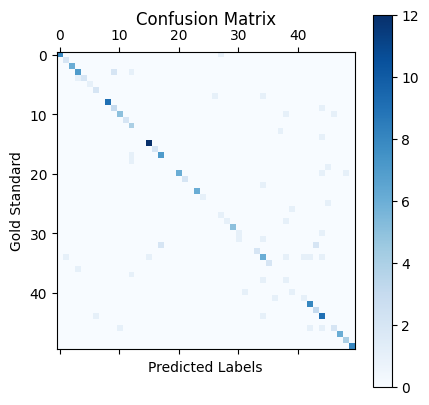

In [48]:
# estrazione dei topic suggeriti (gold standard)
true_labels = [topic[0] for topic in test_data['topics-suggestion']]

# estrazione dei topic predetti
predicted_labels = [topic[0] for topic in test_data['predicted-topics']]

# print del numero di topics
topics = set()
for sublist in test_data['topics-suggestion']:
    for topic in sublist:
        topics.add(topic)

print(f"Numero topic: {len(topics)}")
print('\n')

# calcolo dell'accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy}")
print('\n')

# classification report
report = classification_report(true_labels, predicted_labels, zero_division = 1) # il parametro 'zero_division = 1' serve a gestire le label che non sono rappresentate all'interno del campione in analisi
print(f"Classification report:")                                                 # settando automaticamente a 1 quel punteggio ed evitando che il report generi un error.
print(report)
print('\n')

# confusion matrix
conf_mat = confusion_matrix(true_labels, predicted_labels)

# istruzioni per la visualizzazione della matrice di confusione con Matplotlib
plt.figure(figsize=(10, 8))
plt.matshow(conf_mat, cmap='Blues')
plt.title("Confusion Matrix", pad=20)
plt.colorbar()
plt.ylabel("Gold Standard")
plt.xlabel("Predicted Labels")
plt.show()

Nella topic analysis il modello ha svolto un lavoro complessivamente positivo, attribuendo una label corretta al 77.6% dei testi (accuracy), soprattutto se considerate le dimensioni ristrette del dataset di addestramento e l'alto numero di topics.

Proprio la presenza di così tante label rende difficile la lettura del report e della matrice di confusione. Per per avere una migliore comprensione dei risultati si può analizzare il report con Pandas.

**4.2 Dettaglio delle prestazioni mediante l'uso di Pandas**
- Casi in cui il classificatore ha fatto registrare una precision inferiore a 0.5
- Prestazioni del classificatore in corrispondenza di labels con support maggiore di 2

Il primo step dell'analisi è quello di indagare laddove il classificatore ha fatto fatica ad etichettare correttamente le label. A tal fine, il report viene analizzato come se fosse un dataset attraverso lo strumento DataFrame() di pandas.

In [49]:
# generazione il report come dizionario
report_dict = classification_report(true_labels, predicted_labels, zero_division = 1, output_dict = True)

# creazione di un dataframe dal report
report_df = pd.DataFrame(report_dict).transpose() # il DataFrame creato inverte righe e colonne di default, per evitare ciò, viene utilizzata .transpose(), funzione di pandas che inverte righe e colonne

# filtraggio dei topic con precision bassa (< 0.5)
low_precision_topics = report_df[report_df['precision'] < 0.5]

# print dei topic con la precision più bassa
print('Topic con precision inferiore a 0.5:')
print('\n', low_precision_topics[['precision', 'recall', 'f1-score', 'support']])

Topic con precision inferiore a 0.5:

                                     precision  recall  f1-score  support
getting_spare_card                       0.00     0.0  0.000000      1.0
pending_top_up                           0.00     0.0  0.000000      2.0
top_up_by_bank_transfer_charge           0.00     0.0  0.000000      1.0
top_up_by_card_charge                    0.00     0.0  0.000000      1.0
top_up_by_cash_or_cheque                 0.25     0.5  0.333333      2.0
top_up_limits                            0.00     1.0  0.000000      0.0
transfer_not_received_by_recipient       0.00     1.0  0.000000      0.0


Il modello ha registrato risultati peggiori in corrispondenza di label poco rappresentate (7), ciò vuol dire che non ha avuto abbastanza esempi per apprendere.

Le metriche di topics come '**getting_spare_card**', '**pending_top_up**', '**top_up_by_bank_transfer_charge**' e '**top_up_by_card_charge**', che registrano valore 0 sia in precision che in recall, sono da leggersi alla luce della scarsità di esempi a disposizione, 1 o 2 al massimo per label.

I valori "anomali" di recall registrati dalle label con support 0 (dunque nessuna attestazione), sono invece settati automaticamente dal parametro 'zero_division', che evita errori dovuti a divisioni per zero, assegnando un valore predefinito (in questo caso 1) quando non è possibile calcolare una metrica..

A questo punto, può essere utile guardare alle prestazioni del classificatore in relazione alla presenza di ciascun topic nel campione. Si può utilizzare come punto di riferimento la metrica 'support', che fornisce il numero di occorrenze per ogni label registrata.

In [50]:
# filtraggio per topic maggiormente rappresentati (più di 2 occorrenze)
most_represented_topics = report_df[report_df['support'] > 2]

# i topics vengono ordinati in modo decrescente per una migliore visualizzazione dei dati
most_represented_topics = most_represented_topics.sort_values(by='support', ascending=False)  # viene utilizzata sort_values(), funzione di pandas che permette di ordinare i valori in base a criteri specifici

# print delle metriche per i topic più rappresentati
print("Topic con support maggiore di 2:")
print(most_represented_topics[['precision', 'recall', 'f1-score', 'support']][2:])  # viene effettuato uno slicing poiché i primi due valori della lista sono medie ('macro avg', 'weighted avg') che, essendo
                                                                                    # valori calcolati sul totale degli esempi, hanno un support di 192.

Topic con support maggiore di 2:
                                     precision    recall  f1-score  support
change_pin                            0.923077  1.000000  0.960000     12.0
receiving_money                       0.545455  0.500000  0.521739     12.0
transfer_into_account                 0.600000  0.818182  0.692308     11.0
atm_support                           0.777778  0.700000  0.736842     10.0
activate_my_card                      1.000000  0.888889  0.941176      9.0
card_about_to_expire                  1.000000  1.000000  1.000000      9.0
transaction_charged_twice             0.800000  1.000000  0.888889      8.0
country_support                       0.777778  0.875000  0.823529      8.0
direct_debit_payment_not_recognised   1.000000  0.750000  0.857143      8.0
visa_or_mastercard                    1.000000  1.000000  1.000000      8.0
card_arrival                          0.833333  0.714286  0.769231      7.0
exchange_via_app                      1.000000  1.00000

Le prestazioni del classificatore migliorano significativamente in relazione a label maggiormente rappresentate all'interno del dataset.

'**change_pin**', '**activate_my_card**', '**card_about_to_expire**' e '**visa_or_mastercard**', labels con un support compreso tra 8 e 12, dunque altamente presenti, registrano punteggi alti nelle tre metriche, talvolta ottimali, come nel caso delle ultime due.

Spostando l'attenzione sulle label che si potrebbero definire mediamente rappresentate (support > 4 < 8), il classificatore mantiene delle buone prestazioni generali, facendo registrare anche in questo prestazioni ottimali per i topic '**exchange_via_app**', '**apple_pay_or_google_pay**', '**verify_source_of_funds**' (support = 6 ) e '**passcode_forgotten**' (support = 5).

Con un support pari o inferiore a 4, le prestazioni generali iniziano a calare, e non si registrano valori ottimali per nessuna label. Tuttavia, i risultati restano ancora accettabili per label come '**card_acceptance**', '**card_not_working**', e '**transfer_fee_charged**', e addirittura buoni per '**verify_top_up**' e '**automatic_top_up**'. In altri casi, il modello incontra difficoltà, come per '**pending_transfer**' (precision = 1.0, recall = 0.0), dove si registrano troppi falsi negativi.

**5. STATISTICS**

La fase finale dell'analisi comprende la realizzazione di due statistiche. Un confronto tra testi e topic lemmatizzati per individuare lemmi 'chiave' che ricorrono in entrambe le categorie e una misurazione delle frasi con sentiment negativo associate a ciascun topic, volta ad individuare quelli percepiti in modo peggiore da parte degli utenti (o che registrano la maggior parte delle problematiche).

**5.1. Confronto testo/topic e individuazione dei lemmi comuni:**

Prima di procedere con le statistiche è necessario estrarre e formattare in un formato unico i dati contenenti testi e topics ('suggested' e 'predicted').

In [51]:
# estrazione dei testi
text_lemmas = [text for text in test_data['lemmatized-text']]   # i testi già lemmatizzati si trovano nella colonna 'lemmatized-text' del dataset

# estrazione dei topics
suggested_topics_wout_underscore = [re.sub('_', ' ', topic[0]) for topic in test_data['topics-suggestion']] # le stringhe dei topics sono annidate in delle liste in cui i singoli token sono separati da un underscore '_';
predicted_topics_wout_underscore = [re.sub('_', ' ', topic[0]) for topic in test_data['predicted-topics']]  # per sostituirlo con uno spazio, in modo da omogenizzare i dati, viene utilizzata un'espressione regolare


# estrazione dei singoli lemmi da ciascuna stringa
text_lemmas = [text.split(' ') for text in text_lemmas]   # viene utilizzato il metodo split() per separare i singoli lemmi
suggested_lemmas = [lemmatizator(topic).split(' ') for topic in suggested_topics_wout_underscore]  # i topics subiscono il passaggio ulteriore della lemmatizzazione
predicted_lemmas = [lemmatizator(topic).split(' ') for topic in predicted_topics_wout_underscore]

# print di controllo
print(text_lemmas[0:10])
print(suggested_lemmas[0:10])
print(predicted_lemmas[0:10])

[['okay', 'use', 'bank', 'card'], ['step', 'receive', 'passcode'], ['mastercard'], ['card', 'expire', 'cost', 'order', 'new', 'fast'], ['activate', 'card'], ['use', 'card', 'want'], ['want', 'morning'], ['set', 'PIN', 'new', 'card'], ['space', 'money', 'transfer', 'travel'], ['account', 'get', 'charge', 'take', 'cash', 'happen']]
[['bank', 'transfer', 'charge'], ['passcode', 'forget'], ['visa', 'mastercard'], ['card', 'expire'], ['activate', 'card'], ['country', 'support'], ['revert'], ['change', 'pin'], ['receive', 'money'], ['cash', 'withdrawal', 'charge']]
[['atm', 'support'], ['passcode', 'forget'], ['visa', 'mastercard'], ['card', 'expire'], ['activate', 'card'], ['card', 'work'], ['limit'], ['change', 'pin'], ['receive', 'money'], ['transfer', 'account']]


In [52]:
# common_finder: funzione che trova gli elementi comuni
def common_finder(texts, labels):
    common_dict = {}   # istanzia un dizionario vuoto in cui inserire gli elementi comuni come chiavi e le loro occorrenze come valori
    for i in range(len(texts)):   # itera su ciascun indice della prima lista
        text = set(texts[i])  # ciascuna sottolista viene convertita in set() per poter applicare intersection()
        label = set(labels[i])
        common_item = text.intersection(label)  # usa il metodo intersection() per ottenere un set degli elementi comuni
        for item in common_item:   # itera attraverso gli elementi comuni
            if item in common_dict:  # se l'elemento è già presente nel dizionario
                common_dict[item] += 1  # aumenta il suo conteggio di 1
            else:
                common_dict[item] = 1   # se non è presente, crea una nuova chiave con valore 1
    return common_dict  # restituisce il dizionario finale

In [53]:
# estrazione dei lemmi comuni tra testi e topic suggeriti
key_lemmas_gold_std = common_finder(text_lemmas, suggested_lemmas)

# estrazione dei lemmi comuni tra testi e topic predetti
key_lemmas_predicted = common_finder(text_lemmas, predicted_lemmas)

# print di controllo
print(f'Lemmi chiave text/suggested-topics: {len(key_lemmas_gold_std)}')
print(key_lemmas_gold_std.items())
print('\n')
print(f'Lemmi chiave text/predicted-topics: {len(key_lemmas_predicted)}')
print(key_lemmas_predicted.items())

Lemmi chiave text/suggested-topics: 42
dict_items([('bank', 1), ('passcode', 5), ('mastercard', 2), ('expire', 8), ('card', 39), ('activate', 6), ('money', 9), ('cash', 4), ('charge', 12), ('twice', 3), ('transaction', 3), ('app', 6), ('lose', 1), ('account', 13), ('transfer', 18), ('link', 2), ('country', 4), ('fund', 5), ('work', 4), ('top', 2), ('contactless', 2), ('pay', 2), ('apple', 1), ('decline', 2), ('payment', 4), ('change', 9), ('block', 1), ('pin', 3), ('exchange', 2), ('debit', 6), ('direct', 5), ('beneficiary', 2), ('receive', 1), ('atm', 5), ('source', 4), ('visa', 2), ('order', 2), ('deposit', 1), ('cancel', 2), ('terminate', 1), ('age', 1), ('forget', 1)])


Lemmi chiave text/predicted-topics: 39
dict_items([('passcode', 5), ('mastercard', 2), ('expire', 8), ('card', 43), ('activate', 6), ('money', 4), ('account', 14), ('twice', 3), ('charge', 11), ('transaction', 4), ('app', 6), ('lose', 2), ('transfer', 14), ('link', 2), ('country', 4), ('fund', 5), ('work', 5), ('co

In [54]:
import os

os.makedirs('images', exist_ok=True)

In [55]:
# bar_chart_generator: funzione per generare un grafico a barre partendo da un dizionario
def bar_chart_generator(data, title, color, xlabel, ylabel):  # 5 argomenti (dizionario, titolo, colore, x label, y label) in modo tale che possa essere riutilizzata
    plt.figure(figsize=(10, 6))
    plt.bar(data.keys(), data.values(), color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=90)
    plt.tight_layout()
    file_name = title.lower().replace(' ', '_') + '.png'
    plt.savefig(f'images/{file_name}')
    plt.show()

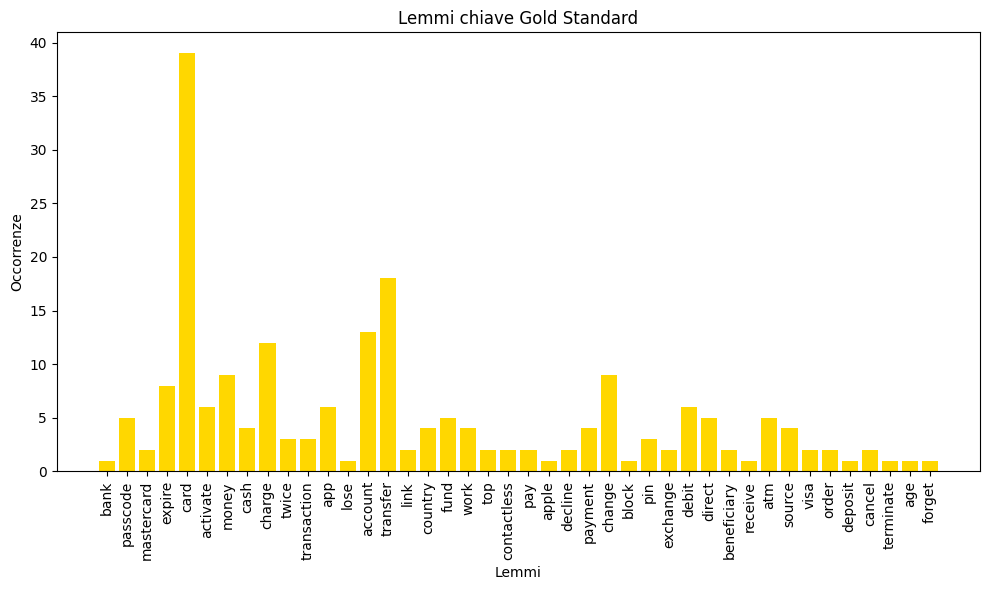

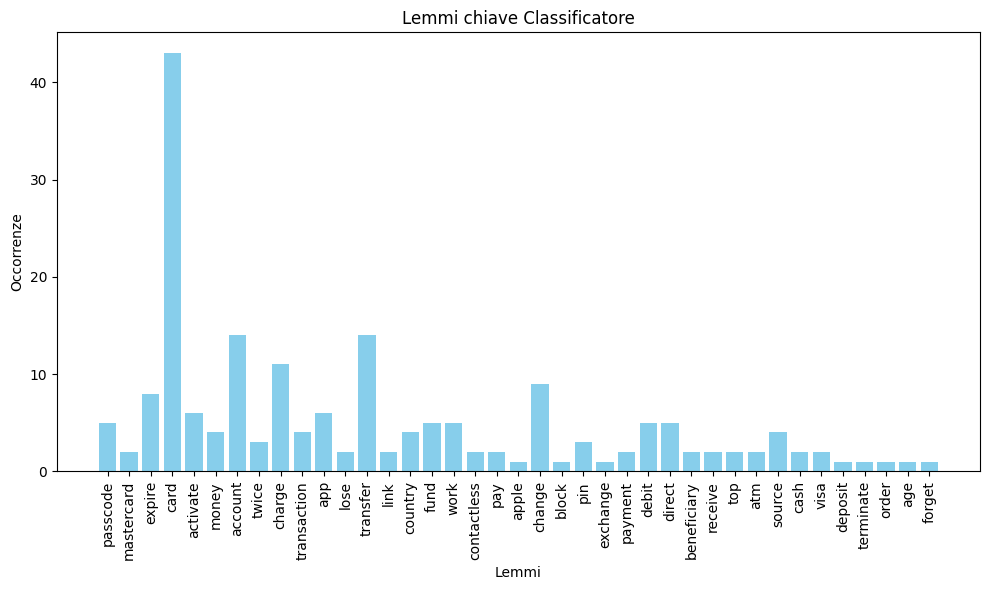

In [56]:
# generazione del grafico per i lemmi comuni con i topic suggeriti
bar_chart_generator(key_lemmas_gold_std, "Lemmi chiave Gold Standard", 'gold', 'Lemmi', 'Occorrenze')  # applica la funzione bar_chart_generator che prende come argomenti (dizionario, titolo del grafico, colore)
print('\n')
# generazione del grafico per i lemmi comuni con i topic predetti
bar_chart_generator(key_lemmas_predicted, "Lemmi chiave Classificatore", 'skyblue', 'Lemmi', 'Occorrenze')

I grafici mostrano analogie e differenze nella gestione dell'informazione lessicale tra il gold standard (ovvero il dato pre-etichettato) e il classificatore.

In entrambi i grafici il lemma '**card**' è il più frequente (39 occorrenze nel G.S., 43 nel classificatore), segno che il classificatore è riuscito ad intercettare correttamente l'argomento principale nelle interazioni degli utenti. A provare ulteriormente questo dato è la distribuzione, praticamente sovrapponibile, dei lemmi appartenenti allo stesso campo semantico '**mastercard**' (2), '**expire**' (8), '**activate**' (6), '**contactless**' (2), '**visa**' (2).

Un'analisi delle differenze, mostra invece la maggiore ricchezza lessicale catturata dal gold standard rispetto al classificatore. Lemmi come '**bank**', '**decline**' e '**cancel**' appaiono esclusivamente nel primo grafico, benché le loro frequenze non siano alte (1 o 2 al massimo). Altri lemmi risultano sottorappresentati dal classificatore, è il caso di '**money**' (9-4), '**cash**' (4-2), '**transfer**' (18-14), '**payment**' (4-2), '**atm**' (5-2).

In conclusione, il classificatore identifica in modo corretto i lemmi che riguardano le carte e le operazioni correlate, come scadenza, arrivo, attivazione, tipologia, tendendo , in alcuni casi, a enfatizzare eccessivamente questo macro-topic. D'altra parte, il sottodimensionamento, o mancata rappresentazione, di lemmi più generici, come quelli relativi al denaro in generale ("**cash**", "**money**") e ai movimenti ("**transfer**"), rivela una difficoltà nel gestire le interazioni che riguardano una gamma di concetti più ampia.     

**5.2. Misurazione dei testi con sentiment negativo associati a ciascun topic.**

Per la realizzazione di questa statistica, è necessario disporre dei sentiment calcolati dal classificatore. Dunque, analogamente a quanto fatto nei passaggi precenti, il sentiment vengono calcolati con metodo Nearest Neighbor, utilizzando la funzione 'predictor'.

In [57]:
# calcolo del sentiment
predicted_sentiments = predictor(test_embeddings, train_embeddings, train_data['sentiment-suggestion'])

# creazione della colonna con i sentiment predetti dal classificatore
test_data['predicted-sentiment'] = predicted_sentiments

# print di controllo
print(test_data[['text','topics-suggestion', 'sentiment-suggestion','predicted-topics', 'predicted-sentiment']][:10])

                                                  text  \
836            Is it okay to use a bank card to top up   
477  What steps do I take to receive another passcode?   
350                            Can I get a mastercard?   
892  My card is about to expire. How much does it c...   
855                           Please, activate my card   
261                 Can I use my card anywhere I want?   
215       I want to go back on what I did this morning   
334           How do I set-up my PIN for the new card?   
86   Can I space out how often money is transferred...   
877  My account got charged for taking out cash, wh...   

                    topics-suggestion sentiment-suggestion  \
836  [top_up_by_bank_transfer_charge]             positive   
477              [passcode_forgotten]              neutral   
350              [visa_or_mastercard]             positive   
892            [card_about_to_expire]             negative   
855                [activate_my_card]              

In [58]:
# negative_counter: funzione per contare i sentiment negativi associati ai topics
def negative_counter(data, sentiment_column, topic_column):
    negative_count = {}   # dichiara un dizionario vuoto per il conteggio dei sentiment negativi
    for i, row in data.iterrows():  # itera attraverso le righe del dataset
        topic = row[topic_column][0]  # estrae il primo elemento dalla lista dei topics
        if row[sentiment_column] == 'negative': # controlla che il sentiment sia negativo
            if topic in negative_count:   # se il topic è gia nel dizionario
                negative_count[topic] += 1  # aggiorna il conteggio del sentiment
            else:                         # se il topic non è nel dizionario
                negative_count[topic] = 1   # crea la chiave con il topic e setta il conteggio a 1

    return negative_count   # restituisce il dizionario così strutturato {topic: conteggio di quante volte il sentiment negativo è stato associato al topic}

Frasi con sentiment negativo per topic suggeriti:
dict_items([('card_about_to_expire', 5), ('cash_withdrawal_charge', 1), ('receiving_money', 2), ('lost_or_stolen_card', 1), ('declined_card_payment', 1), ('declined_transfer', 1), ('atm_support', 2), ('top_up_reverted', 1), ('exchange_via_app', 3), ('terminate_account', 2), ('cancel_transfer', 1), ('direct_debit_payment_not_recognised', 2)])

Frasi con sentiment negativo per topic predetti:
dict_items([('receiving_money', 3), ('pin_blocked', 1), ('beneficiary_not_allowed', 1), ('card_about_to_expire', 6), ('pending_card_payment', 1), ('atm_support', 3), ('automatic_top_up', 1), ('exchange_via_app', 1), ('country_support', 1), ('terminate_account', 2)])




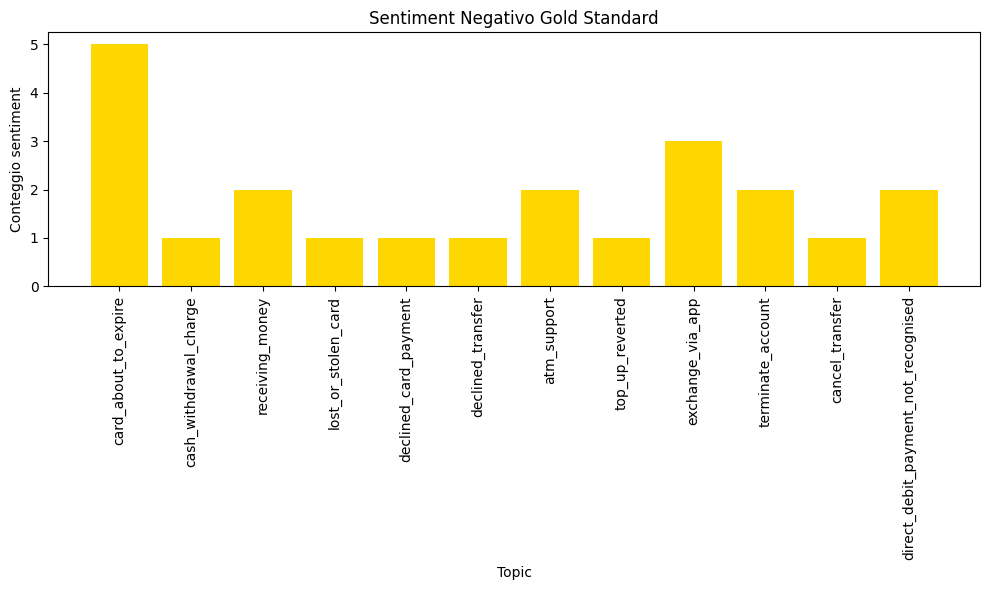

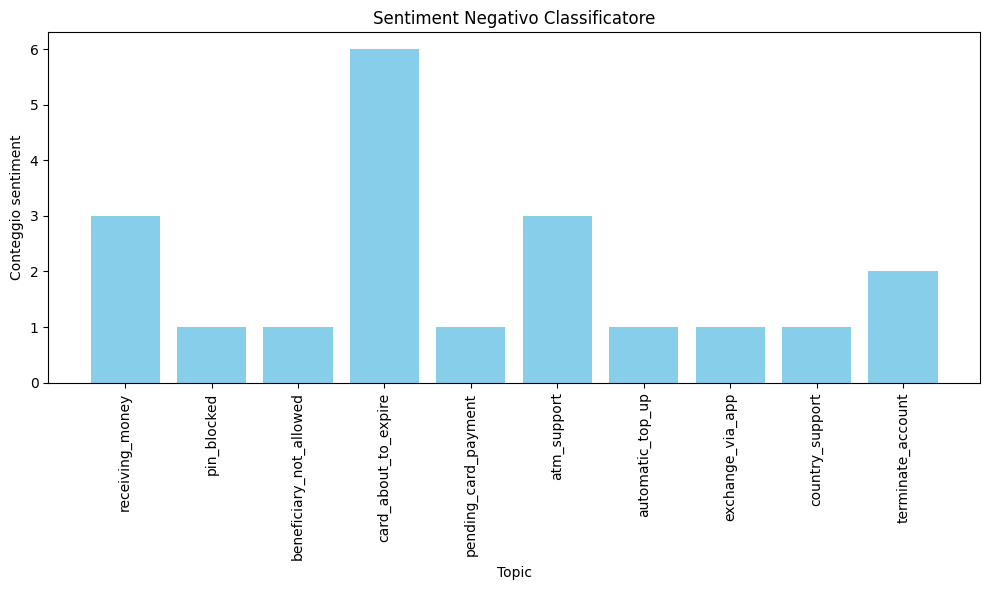

In [59]:
# utilizzo della funzione per contare i sentiment negativi per topic suggeriti e predetti
negative_suggested_count = negative_counter(test_data, 'sentiment-suggestion', 'topics-suggestion')
negative_predicted_count = negative_counter(test_data, 'predicted-sentiment', 'predicted-topics')

# Print di controllo per i risultati
print("Frasi con sentiment negativo per topic suggeriti:")
print(negative_suggested_count.items())

print("\nFrasi con sentiment negativo per topic predetti:")
print(negative_predicted_count.items())
print('\n')

# generazione del grafico per i topic suggeriti
bar_chart_generator(negative_suggested_count, "Sentiment Negativo Gold Standard", "gold", 'Topic', 'Conteggio sentiment') # riutilizza la funzione dichiarata in 5.1 bar_chart_generator
print('\n')
# generazione del grafico per i topic predetti
bar_chart_generator(negative_predicted_count, "Sentiment Negativo Classificatore", "skyblue", 'Topic', 'Conteggio sentiment')


La distribuzione del sentiment negativo rispetto ai topics rispecchia le tendenze generali e le criticità già emerse nell'analisi dei lemmi chiave.

Anche in questo caso, il grafico relativo ai dati pre-etichettati appare più bilanciato, con il sentiment distribuito in 12 topics, a fronte dei 10 individuati dal classificatore. Si nota, inoltre, che non vi è una sovrapposizione perfetta dei due grafici. Le label '**cash_withdrawal_charge**', '**declined_card_payment**', '**declined_transfer**', e '**direct_debit_payment_not_recognised**' sono esclusive del Gold Standard, mentre '**pin_blocked**', '**beneficiary_not_allowed**', e '**automatic_top_up**', appaiono solamente nei dati del classificatore.

In entrambi i grafici il topic che ha registrato maggiormente un sentiment negativo è '**card_about_to_expire**' (5-6), dato che conferma una presenza robusta di elementi relativi alle carte di credito nel train set.
In generale, il classificatore sembra avere difficoltà in corrispondenza di un informazione testuale più particolareggiata, a testimoniare questa tendenza è, in primis, l'enfasi che viene posta sui topic più rappresentati, i quali sia in questa statistica che al punto 5.1 ne escono leggermente sovradimensionati, in secundis, un'etichettatura condotta attraverso label più generiche, come '**receiving_money**' (2-3), '**beneficiary_not_allowed**' (0-1) e '**atm_support**' (2-3), mentre il G.S. utilizza un maggior numero di label, lessicalmente più ricche e accurate.